In [1]:
import sys
import pandas as pd
import numpy as np
import sklearn
import matplotlib
import seaborn

print(sys.version)
print("pandas", pd.__version__, "| numpy", np.__version__, "| sklearn", sklearn.__version__)

try:
    import xgboost
    print("xgboost", xgboost.__version__)
except ImportError:
    print("xgboost MISSING")

try:
    import shap
    print("shap", shap.__version__)
except ImportError:
    print("shap MISSING")

3.13.9 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 19:09:58) [MSC v.1929 64 bit (AMD64)]
pandas 2.3.3 | numpy 2.3.5 | sklearn 1.7.2
xgboost 3.4.1
shap 0.52.0


In [2]:
import os
print(os.getcwd())
print(os.listdir("../data"))

C:\Users\HP\Projects\rul-turbofan-fd001\notebooks
['.ipynb_checkpoints', 'RUL_FD001.txt', 'test_FD001.txt', 'train_FD001.txt']


In [3]:
import pandas as pd

train_df = pd.read_csv(
    "../data/train_FD001.txt",
    sep=r"\s+",
    header=None
)

train_df.head()

,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [4]:
train_df.shape

(20631, 26)

In [5]:
# train_df.columns = ma je add karvi te column +na +heade+r ma add thai

columns = [
    "unit", "cycle",
    "setting_1", "setting_2", "setting_3"
]

columns += [f"s_{i}" for i in range(1, 22)]

train_df.columns = columns

train_df.head()

,unit,cycle,setting_1,setting_2,setting_3,s_1,s_2,s_3,s_4,s_5,...,s_12,s_13,s_14,s_15,s_16,s_17,s_18,s_19,s_20,s_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [6]:
test_df = pd.read_csv(
    "../data/test_FD001.txt",
    sep=r"\s+",
    header=None
)

test_df.head()

,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
0,1,1,0.0023,0.0003,100.0,518.67,643.02,1585.29,1398.21,14.62,...,521.72,2388.03,8125.55,8.4052,0.03,392,2388,100.0,38.86,23.3735
1,1,2,-0.0027,-0.0003,100.0,518.67,641.71,1588.45,1395.42,14.62,...,522.16,2388.06,8139.62,8.3803,0.03,393,2388,100.0,39.02,23.3916
2,1,3,0.0003,0.0001,100.0,518.67,642.46,1586.94,1401.34,14.62,...,521.97,2388.03,8130.10,8.4441,0.03,393,2388,100.0,39.08,23.4166
3,1,4,0.0042,0.0000,100.0,518.67,642.44,1584.12,1406.42,14.62,...,521.38,2388.05,8132.90,8.3917,0.03,391,2388,100.0,39.00,23.3737
4,1,5,0.0014,0.0000,100.0,518.67,642.51,1587.19,1401.92,14.62,...,522.15,2388.03,8129.54,8.4031,0.03,390,2388,100.0,38.99,23.4130


In [7]:
test_df.columns = columns

test_df.head()

,unit,cycle,setting_1,setting_2,setting_3,s_1,s_2,s_3,s_4,s_5,...,s_12,s_13,s_14,s_15,s_16,s_17,s_18,s_19,s_20,s_21
0,1,1,0.0023,0.0003,100.0,518.67,643.02,1585.29,1398.21,14.62,...,521.72,2388.03,8125.55,8.4052,0.03,392,2388,100.0,38.86,23.3735
1,1,2,-0.0027,-0.0003,100.0,518.67,641.71,1588.45,1395.42,14.62,...,522.16,2388.06,8139.62,8.3803,0.03,393,2388,100.0,39.02,23.3916
2,1,3,0.0003,0.0001,100.0,518.67,642.46,1586.94,1401.34,14.62,...,521.97,2388.03,8130.10,8.4441,0.03,393,2388,100.0,39.08,23.4166
3,1,4,0.0042,0.0000,100.0,518.67,642.44,1584.12,1406.42,14.62,...,521.38,2388.05,8132.90,8.3917,0.03,391,2388,100.0,39.00,23.3737
4,1,5,0.0014,0.0000,100.0,518.67,642.51,1587.19,1401.92,14.62,...,522.15,2388.03,8129.54,8.4031,0.03,390,2388,100.0,38.99,23.4130


In [8]:
rul_df = pd.read_csv(
    "../data/RUL_FD001.txt",
    header=None
)

rul_df.head()

,0
0,112
1,98
2,69
3,82
4,91


In [9]:
rul_df.shape

(100, 1)

In [10]:
# df.groupby("જેના આધારે group")["જે column પર calculation કરવી છે"].function()

max_cycle = train_df.groupby("unit")["cycle"].max()
max_cycle.head()

unit
1    192
2    287
3    179
4    189
5    269
Name: cycle, dtype: int64

In [11]:
train_df["RUL"] = train_df["unit"].map(max_cycle) - train_df["cycle"]

In [12]:
train_df[["unit", "cycle", "RUL"]].head()

,unit,cycle,RUL
0,1,1,191
1,1,2,190
2,1,3,189
3,1,4,188
4,1,5,187


In [13]:
train_df[train_df["unit"] == 1].tail()

,unit,cycle,setting_1,setting_2,setting_3,s_1,s_2,s_3,s_4,s_5,...,s_13,s_14,s_15,s_16,s_17,s_18,s_19,s_20,s_21,RUL
187,1,188,-0.0067,0.0003,100.0,518.67,643.75,1602.38,1422.78,14.62,...,2388.23,8117.69,8.5207,0.03,396,2388,100.0,38.51,22.9588,4
188,1,189,-0.0006,0.0002,100.0,518.67,644.18,1596.17,1428.01,14.62,...,2388.33,8117.51,8.5183,0.03,395,2388,100.0,38.48,23.1127,3
189,1,190,-0.0027,0.0001,100.0,518.67,643.64,1599.22,1425.95,14.62,...,2388.35,8112.58,8.5223,0.03,398,2388,100.0,38.49,23.0675,2
190,1,191,-0.0000,-0.0004,100.0,518.67,643.34,1602.36,1425.77,14.62,...,2388.30,8114.61,8.5174,0.03,394,2388,100.0,38.45,23.1295,1
191,1,192,0.0009,-0.0000,100.0,518.67,643.54,1601.41,1427.20,14.62,...,2388.32,8110.93,8.5113,0.03,396,2388,100.0,38.48,22.9649,0


In [14]:
train_df.groupby("unit")["RUL"].min().head()

unit
1    0
2    0
3    0
4    0
5    0
Name: RUL, dtype: int64

In [15]:
train_df["RUL"].describe()

count    20631.000000
mean       107.807862
std         68.880990
min          0.000000
25%         51.000000
50%        103.000000
75%        155.000000
max        361.000000
Name: RUL, dtype: float64

In [16]:
train_df[train_df["RUL"] == train_df["RUL"].max()][["unit", "cycle", "RUL"]]

,unit,cycle,RUL
13631,69,1,361


In [17]:
y = train_df["RUL"]

X = train_df.drop(columns=["RUL"])

In [18]:
y.head()

0    191
1    190
2    189
3    188
4    187
Name: RUL, dtype: int64

In [19]:
X.shape

(20631, 26)

In [20]:
X.columns

Index(['unit', 'cycle', 'setting_1', 'setting_2', 'setting_3', 's_1', 's_2',
       's_3', 's_4', 's_5', 's_6', 's_7', 's_8', 's_9', 's_10', 's_11', 's_12',
       's_13', 's_14', 's_15', 's_16', 's_17', 's_18', 's_19', 's_20', 's_21'],
      dtype='object')

In [21]:
train_df.isnull().sum().sum()

np.int64(0)

In [22]:
train_df.nunique()

unit          100
cycle         362
setting_1     158
setting_2      13
setting_3       1
s_1             1
s_2           310
s_3          3012
s_4          4051
s_5             1
s_6             2
s_7           513
s_8            53
s_9          6403
s_10            1
s_11          159
s_12          427
s_13           56
s_14         6078
s_15         1918
s_16            1
s_17           13
s_18            1
s_19            1
s_20          120
s_21         4745
RUL           362
dtype: int64

In [23]:
train_df[["setting_3", "s_1", "s_5", "s_10", "s_16", "s_18", "s_19"]].nunique()

setting_3    1
s_1          1
s_5          1
s_10         1
s_16         1
s_18         1
s_19         1
dtype: int64

In [24]:
# A badhi column thi data ma kai change thato nathi ke ke te nunique = 1 vali columns chhe

constant_columns = [
    "setting_3",
    "s_1",
    "s_5",
    "s_10",
    "s_16",
    "s_18",
    "s_19"
]

# X = X.drop(columns=constant_columns)
# a ak var drop thai gai pachhi error ave atle me ane # kari didhu chhe 

In [25]:
X.shape

(20631, 26)

In [26]:
X.columns

Index(['unit', 'cycle', 'setting_1', 'setting_2', 'setting_3', 's_1', 's_2',
       's_3', 's_4', 's_5', 's_6', 's_7', 's_8', 's_9', 's_10', 's_11', 's_12',
       's_13', 's_14', 's_15', 's_16', 's_17', 's_18', 's_19', 's_20', 's_21'],
      dtype='object')

In [27]:
X.describe().T

,count,mean,std,min,25%,50%,75%,max
unit,20631.0,51.506568,2.922763e+01,1.0000,26.0000,52.0000,77.0000,100.0000
cycle,20631.0,108.807862,6.888099e+01,1.0000,52.0000,104.0000,156.0000,362.0000
setting_1,20631.0,-0.000009,2.187313e-03,-0.0087,-0.0015,0.0000,0.0015,0.0087
setting_2,20631.0,0.000002,2.930621e-04,-0.0006,-0.0002,0.0000,0.0003,0.0006
setting_3,20631.0,100.000000,0.000000e+00,100.0000,100.0000,100.0000,100.0000,100.0000
s_1,20631.0,518.670000,6.537152e-11,518.6700,518.6700,518.6700,518.6700,518.6700
s_2,20631.0,642.680934,5.000533e-01,641.2100,642.3250,642.6400,643.0000,644.5300
s_3,20631.0,1590.523119,6.131150e+00,1571.0400,1586.2600,1590.1000,1594.3800,1616.9100
s_4,20631.0,1408.933782,9.000605e+00,1382.2500,1402.3600,1408.0400,1414.5550,1441.4900
s_5,20631.0,14.620000,3.394700e-12,14.6200,14.6200,14.6200,14.6200,14.6200


In [28]:
X.corr(numeric_only=True)

,unit,cycle,setting_1,setting_2,setting_3,s_1,s_2,s_3,s_4,s_5,...,s_12,s_13,s_14,s_15,s_16,s_17,s_18,s_19,s_20,s_21
unit,1.000000,0.078753,-0.017895,-0.006197,NaN,NaN,0.014133,0.012621,0.026116,NaN,...,-0.031882,0.044230,-0.059473,0.022486,NaN,0.013513,NaN,NaN,-0.020589,-0.016465
cycle,0.078753,1.000000,-0.004527,0.016132,NaN,NaN,0.549898,0.543947,0.624577,NaN,...,-0.611354,0.477523,0.370324,0.588676,NaN,0.566995,NaN,NaN,-0.583597,-0.585923
setting_1,-0.017895,-0.004527,1.000000,0.011660,NaN,NaN,0.009030,-0.005651,0.009544,NaN,...,-0.001491,0.002318,-0.004469,0.007652,NaN,0.002599,NaN,NaN,-0.005713,-0.014559
setting_2,-0.006197,0.016132,0.011660,1.000000,NaN,NaN,0.007266,0.009068,0.014673,NaN,...,-0.010923,0.018156,-0.006310,0.014156,NaN,0.012280,NaN,NaN,-0.010554,-0.007846
setting_3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
s_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
s_2,0.014133,0.549898,0.009030,0.007266,NaN,NaN,1.000000,0.602610,0.714949,NaN,...,-0.724578,0.661792,0.179752,0.675975,NaN,0.629886,NaN,NaN,-0.661841,-0.668050
s_3,0.012621,0.543947,-0.005651,0.009068,NaN,NaN,0.602610,1.000000,0.678413,NaN,...,-0.680307,0.600963,0.237137,0.639921,NaN,0.600017,NaN,NaN,-0.625941,-0.633901
s_4,0.026116,0.624577,0.009544,0.014673,NaN,NaN,0.714949,0.678413,1.000000,NaN,...,-0.815591,0.745158,0.190748,0.758459,NaN,0.703499,NaN,NaN,-0.748067,-0.745193
s_5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [29]:
# df["column1"].corr(df["column2"])

train_df.corr(numeric_only=True)["RUL"].sort_values()

cycle       -0.736241
s_11        -0.696228
s_4         -0.678948
s_15        -0.642667
s_2         -0.606484
s_17        -0.606154
s_3         -0.584520
s_8         -0.563968
s_13        -0.562569
s_9         -0.390102
s_14        -0.306769
s_6         -0.128348
setting_1   -0.003198
setting_2   -0.001948
unit         0.078753
s_20         0.629428
s_21         0.635662
s_7          0.657223
s_12         0.671983
RUL          1.000000
setting_3         NaN
s_1               NaN
s_5               NaN
s_10              NaN
s_16              NaN
s_18              NaN
s_19              NaN
Name: RUL, dtype: float64

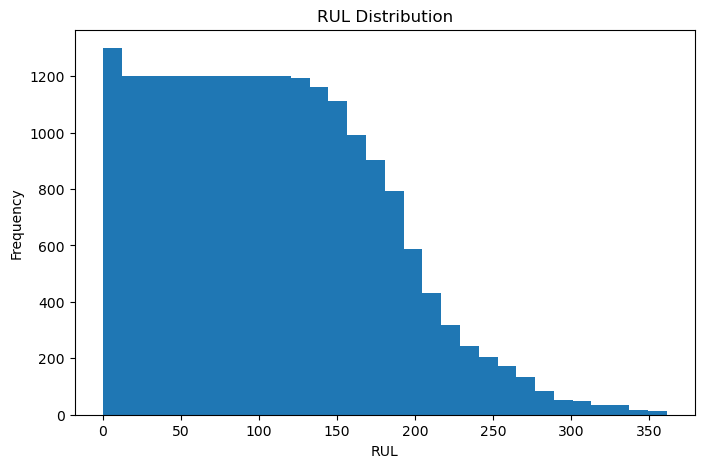

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(train_df["RUL"], bins=30)
plt.xlabel("RUL")
plt.ylabel("Frequency")
plt.title("RUL Distribution")
plt.show()

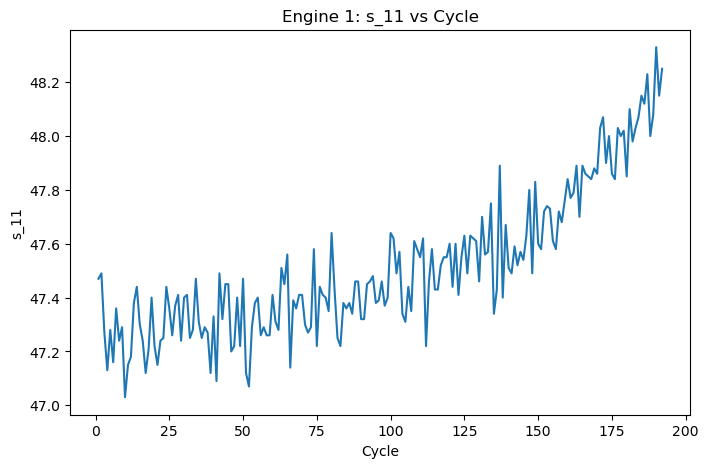

In [31]:
import matplotlib.pyplot as plt

engine_1 = train_df[train_df["unit"] == 1]

plt.figure(figsize=(8, 5))
plt.plot(engine_1["cycle"], engine_1["s_11"])
plt.xlabel("Cycle")
plt.ylabel("s_11")
plt.title("Engine 1: s_11 vs Cycle")
plt.show()

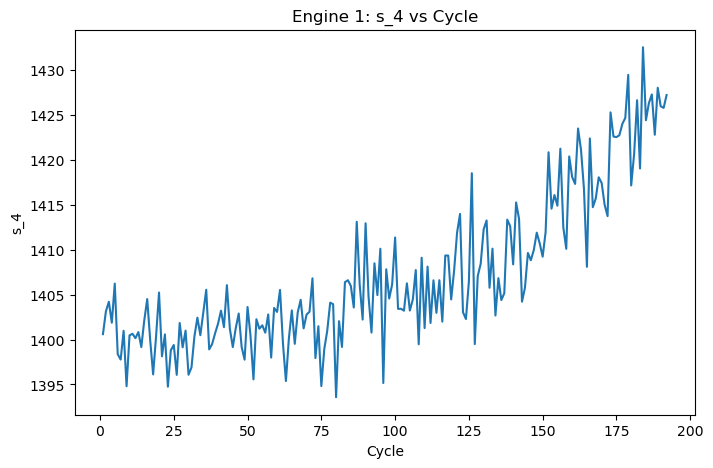

In [32]:
plt.figure(figsize=(8, 5))

plt.plot(engine_1["cycle"], engine_1["s_4"])

plt.xlabel("Cycle")
plt.ylabel("s_4")
plt.title("Engine 1: s_4 vs Cycle")

plt.show()

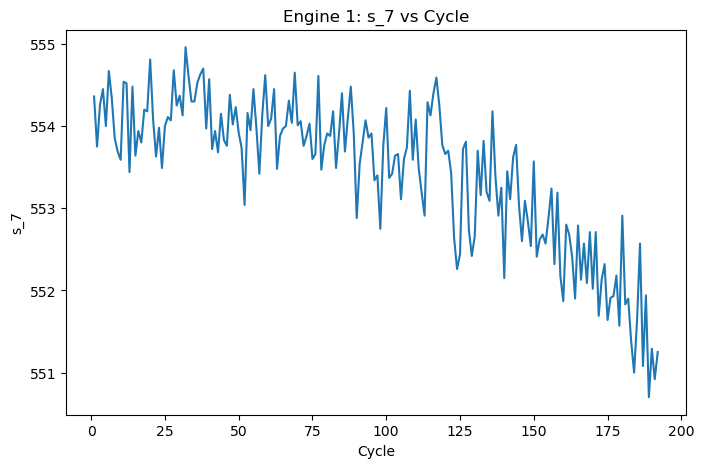

In [33]:
plt.figure(figsize=(8, 5))

plt.plot(engine_1["cycle"], engine_1["s_7"])

plt.xlabel("Cycle")
plt.ylabel("s_7")
plt.title("Engine 1: s_7 vs Cycle")

plt.show()

In [34]:
train_df["s_4_roll_mean_5"] = (
    train_df.groupby("unit")["s_4"]
    .rolling(5)
    .mean()
    .reset_index(level=0, drop=True)
)

train_df[["unit", "cycle", "s_4", "s_4_roll_mean_5"]].head(10)

,unit,cycle,s_4,s_4_roll_mean_5
0,1,1,1400.60,NaN
1,1,2,1403.14,NaN
2,1,3,1404.20,NaN
3,1,4,1401.87,NaN
4,1,5,1406.22,1403.206
5,1,6,1398.37,1402.760
6,1,7,1397.77,1401.686
7,1,8,1400.97,1401.040
8,1,9,1394.80,1399.626
9,1,10,1400.46,1398.474


In [35]:
train_df["s_4_roll_std_5"] = (
    train_df.groupby("unit")["s_4"]
    .rolling(5)
    .std()
    .reset_index(level=0, drop=True)
)

train_df[["unit", "cycle", "s_4", "s_4_roll_mean_5", "s_4_roll_std_5"]].head(10)

,unit,cycle,s_4,s_4_roll_mean_5,s_4_roll_std_5
0,1,1,1400.60,NaN,NaN
1,1,2,1403.14,NaN,NaN
2,1,3,1404.20,NaN,NaN
3,1,4,1401.87,NaN,NaN
4,1,5,1406.22,1403.206,2.159440
5,1,6,1398.37,1402.760,2.926337
6,1,7,1397.77,1401.686,3.648360
7,1,8,1400.97,1401.040,3.367046
8,1,9,1394.80,1399.626,4.289514
9,1,10,1400.46,1398.474,2.458603


In [36]:
import numpy as np

def calculate_slope(values):
    x = np.arange(len(values))
    slope = np.polyfit(x, values, 1)[0]
    return slope

In [37]:
x = np.arange(5)
values = [100, 102, 104, 106, 108]

result = np.polyfit(x, values, 1)

print(result)
print("Slope:", result[0])

[  2. 100.]
Slope: 2.0000000000000164


In [38]:
train_df[
    ["unit", "cycle", "s_4",
     "s_4_roll_mean_5", "s_4_roll_std_5"]
].head(10)

,unit,cycle,s_4,s_4_roll_mean_5,s_4_roll_std_5
0,1,1,1400.60,NaN,NaN
1,1,2,1403.14,NaN,NaN
2,1,3,1404.20,NaN,NaN
3,1,4,1401.87,NaN,NaN
4,1,5,1406.22,1403.206,2.159440
5,1,6,1398.37,1402.760,2.926337
6,1,7,1397.77,1401.686,3.648360
7,1,8,1400.97,1401.040,3.367046
8,1,9,1394.80,1399.626,4.289514
9,1,10,1400.46,1398.474,2.458603


In [39]:
train_df[["unit", "cycle", "s_4_roll_mean_5", "s_4_roll_std_5"]].tail()

,unit,cycle,s_4_roll_mean_5,s_4_roll_std_5
20626,100,196,1427.270,4.656871
20627,100,197,1430.090,2.555181
20628,100,198,1429.940,2.660160
20629,100,199,1429.764,2.888690
20630,100,200,1429.812,2.934684


In [40]:
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (20631, 29)
Test shape: (13096, 26)


In [41]:
test_df.columns

Index(['unit', 'cycle', 'setting_1', 'setting_2', 'setting_3', 's_1', 's_2',
       's_3', 's_4', 's_5', 's_6', 's_7', 's_8', 's_9', 's_10', 's_11', 's_12',
       's_13', 's_14', 's_15', 's_16', 's_17', 's_18', 's_19', 's_20', 's_21'],
      dtype='object')

In [42]:
test_df["s_4_roll_mean_5"] = (
    test_df.groupby("unit")["s_4"]
    .rolling(5)
    .mean()
    .reset_index(level=0, drop=True)
)

test_df["s_4_roll_std_5"] = (
    test_df.groupby("unit")["s_4"]
    .rolling(5)
    .std()
    .reset_index(level=0, drop=True)
)

In [43]:
test_df.shape

(13096, 28)

In [44]:
train_df["s_11_roll_mean_5"] = (
    train_df.groupby("unit")["s_11"]
    .rolling(5)
    .mean()
    .reset_index(level=0, drop=True)
)

train_df["s_11_roll_std_5"] = (
    train_df.groupby("unit")["s_11"]
    .rolling(5)
    .std()
    .reset_index(level=0, drop=True)
)

In [45]:
test_df["s_11_roll_mean_5"] = (
    test_df.groupby("unit")["s_11"]
    .rolling(5)
    .mean()
    .reset_index(level=0, drop=True)
)

test_df["s_11_roll_std_5"] = (
    test_df.groupby("unit")["s_11"]
    .rolling(5)
    .std()
    .reset_index(level=0, drop=True)
)

In [46]:
test_df[
    ["unit", "cycle",
     "s_4_roll_mean_5", "s_4_roll_std_5",
     "s_11_roll_mean_5", "s_11_roll_std_5"]
].head(10)

,unit,cycle,s_4_roll_mean_5,s_4_roll_std_5,s_11_roll_mean_5,s_11_roll_std_5
0,1,1,NaN,NaN,NaN,NaN
1,1,2,NaN,NaN,NaN,NaN
2,1,3,NaN,NaN,NaN,NaN
3,1,4,NaN,NaN,NaN,NaN
4,1,5,1400.662,4.143902,47.358,0.135720
5,1,6,1400.046,4.779674,47.370,0.120000
6,1,7,1401.930,4.336369,47.332,0.096281
7,1,8,1401.840,4.356300,47.274,0.041593
8,1,9,1403.012,6.266153,47.292,0.060166
9,1,10,1402.356,6.573221,47.258,0.088713


In [47]:
train_df[[
    "s_4_roll_mean_5",
    "s_4_roll_std_5",
    "s_11_roll_mean_5",
    "s_11_roll_std_5"
]].isnull().sum()

s_4_roll_mean_5     400
s_4_roll_std_5      400
s_11_roll_mean_5    400
s_11_roll_std_5     400
dtype: int64

In [48]:
train_df = train_df.dropna().copy()

In [49]:
train_df.shape

(20231, 31)

In [50]:
test_df = test_df.dropna().copy()

test_df.shape

(12696, 30)

In [51]:
y = train_df["RUL"]

X = train_df.drop(columns=["RUL"])

In [52]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (20231, 30)
y shape: (20231,)


In [53]:
X = X.drop(columns=["unit"])

In [54]:
X.shape

(20231, 29)

In [55]:
test_X = test_df.drop(columns=["unit"])

In [56]:
print("X shape:", X.shape)
print("test_X shape:", test_X.shape)

X shape: (20231, 29)
test_X shape: (12696, 29)


In [57]:
list(X.columns) == list(test_X.columns)

True

In [58]:
from sklearn.model_selection import GroupKFold
from sklearn.linear_model import LinearRegression

In [59]:
group_kfold = GroupKFold(n_splits=5)

In [60]:
model = LinearRegression()

In [61]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    model,
    X,
    y,
    cv=group_kfold,
    groups=train_df["unit"],
    scoring="neg_root_mean_squared_error"
)

In [62]:
scores

array([-45.99160761, -43.54217234, -38.81397337, -37.21330201,
       -34.349559  ])

In [63]:
rmse_scores = -scores

print("Fold RMSE:", rmse_scores)
print("Mean RMSE:", rmse_scores.mean())

Fold RMSE: [45.99160761 43.54217234 38.81397337 37.21330201 34.349559  ]
Mean RMSE: 39.98212286601067


In [64]:
baseline_rmse = rmse_scores.mean()

print("Baseline RMSE:", baseline_rmse)

Baseline RMSE: 39.98212286601067


In [65]:
from sklearn.model_selection import GroupKFold

train_idx, val_idx = next(
    group_kfold.split(X, y, groups=train_df["unit"])
)

X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

model.fit(X_train, y_train)
y_pred = model.predict(X_val)

In [66]:
print("Actual RUL:")
print(y_val.head())

print("Predicted RUL:")
print(y_pred[:5])

Actual RUL:
4    187
5    186
6    185
7    184
8    183
Name: RUL, dtype: int64
Predicted RUL:
[174.90397326 183.84391723 181.84773457 186.15041478 184.39198589]


In [67]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_val, y_pred))

print("Validation RMSE:", rmse)

Validation RMSE: 45.99160761039114


In [68]:
print("Baseline Model: Linear Regression")
print("Mean Cross-Validation RMSE:", baseline_rmse)

Baseline Model: Linear Regression
Mean Cross-Validation RMSE: 39.98212286601067


In [69]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42
)

In [70]:
xgb_model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [71]:
xgb_pred = xgb_model.predict(X_val)

In [72]:
xgb_rmse = np.sqrt(mean_squared_error(y_val, xgb_pred))

print("XGBoost Validation RMSE:", xgb_rmse)

XGBoost Validation RMSE: 42.03985303452026


In [73]:
xgb_scores = cross_val_score(
    xgb_model,
    X,
    y,
    cv=group_kfold,
    groups=train_df["unit"],
    scoring="neg_root_mean_squared_error"
)

xgb_rmse_scores = -xgb_scores

print("XGBoost Fold RMSE:", xgb_rmse_scores)
print("XGBoost Mean RMSE:", xgb_rmse_scores.mean())

XGBoost Fold RMSE: [42.03985214 39.00268936 37.33336639 35.57604218 33.03976059]
XGBoost Mean RMSE: 37.39834213256836


In [74]:
print("Linear Regression Mean RMSE:", baseline_rmse)
print("XGBoost Mean RMSE:", xgb_rmse_scores.mean())
print("RMSE Improvement:", baseline_rmse - xgb_rmse_scores.mean())

Linear Regression Mean RMSE: 39.98212286601067
XGBoost Mean RMSE: 37.39834213256836
RMSE Improvement: 2.5837807334423104


In [76]:
model_comparison = pd.DataFrame({
    "Model": ["Linear Regression", "XGBoost"],
    "Mean RMSE": [
        baseline_rmse,
        xgb_rmse_scores.mean()
    ]
})

model_comparison

,Model,Mean RMSE
0,Linear Regression,39.982123
1,XGBoost,37.398342


In [78]:
def phm08_score(y_true, y_pred):
    errors = y_pred - y_true

    score = np.where(
        errors < 0,
        np.exp(-errors / 13) - 1,
        np.exp(errors / 10) - 1
    )

    return np.sum(score)

In [79]:
phm08_score(y_val, y_pred)

np.float64(30924744.31578515)

In [81]:
xgb_phm08_score = phm08_score(y_val, xgb_pred)

xgb_phm08_score

np.float64(15477387.151949652)

In [82]:
errors = xgb_pred - y_val.to_numpy()

print("First 5 actual RUL:", y_val.to_numpy()[:5])
print("First 5 predicted RUL:", xgb_pred[:5])
print("First 5 errors:", errors[:5])

First 5 actual RUL: [187 186 185 184 183]
First 5 predicted RUL: [203.36435 228.19553 221.399   210.39276 203.72244]
First 5 errors: [16.36434937 42.19552612 36.39900208 26.39276123 20.72244263]
